  DewPoint Long-Term Trend Analysis
  (after Fourier seasonal reverse transformation)
  Data range       : 1912-01-01 to 2021-12-31
  Observations     : 40,260 daily records

  Seasonal Model (1st + 2nd harmonic):
    Intercept (mean DewPoint) : 13.7036 °C
    sin(2π·doy/365) coeff     : -4.3441
    cos(2π·doy/365) coeff     : -8.0826
    sin(4π·doy/365) coeff     : 0.0244
    cos(4π·doy/365) coeff     : 0.1317
    Seasonal amplitude (1st)  : 9.1761 °C

  Trend Regression (deseasonalized DewPoint ~ Year):
    Slope           : 0.022535 °C/year
    Slope per decade: 0.2254 °C/decade
    R²              : 0.038348
    p-value         : 0.00e+00
    Std Error       : 0.000562
    95% CI for slope: [0.021433, 0.023638] °C/year

  ✓ SIGNIFICANT (p < 0.05): DewPoint is increasing
    at 0.2254 °C per decade.


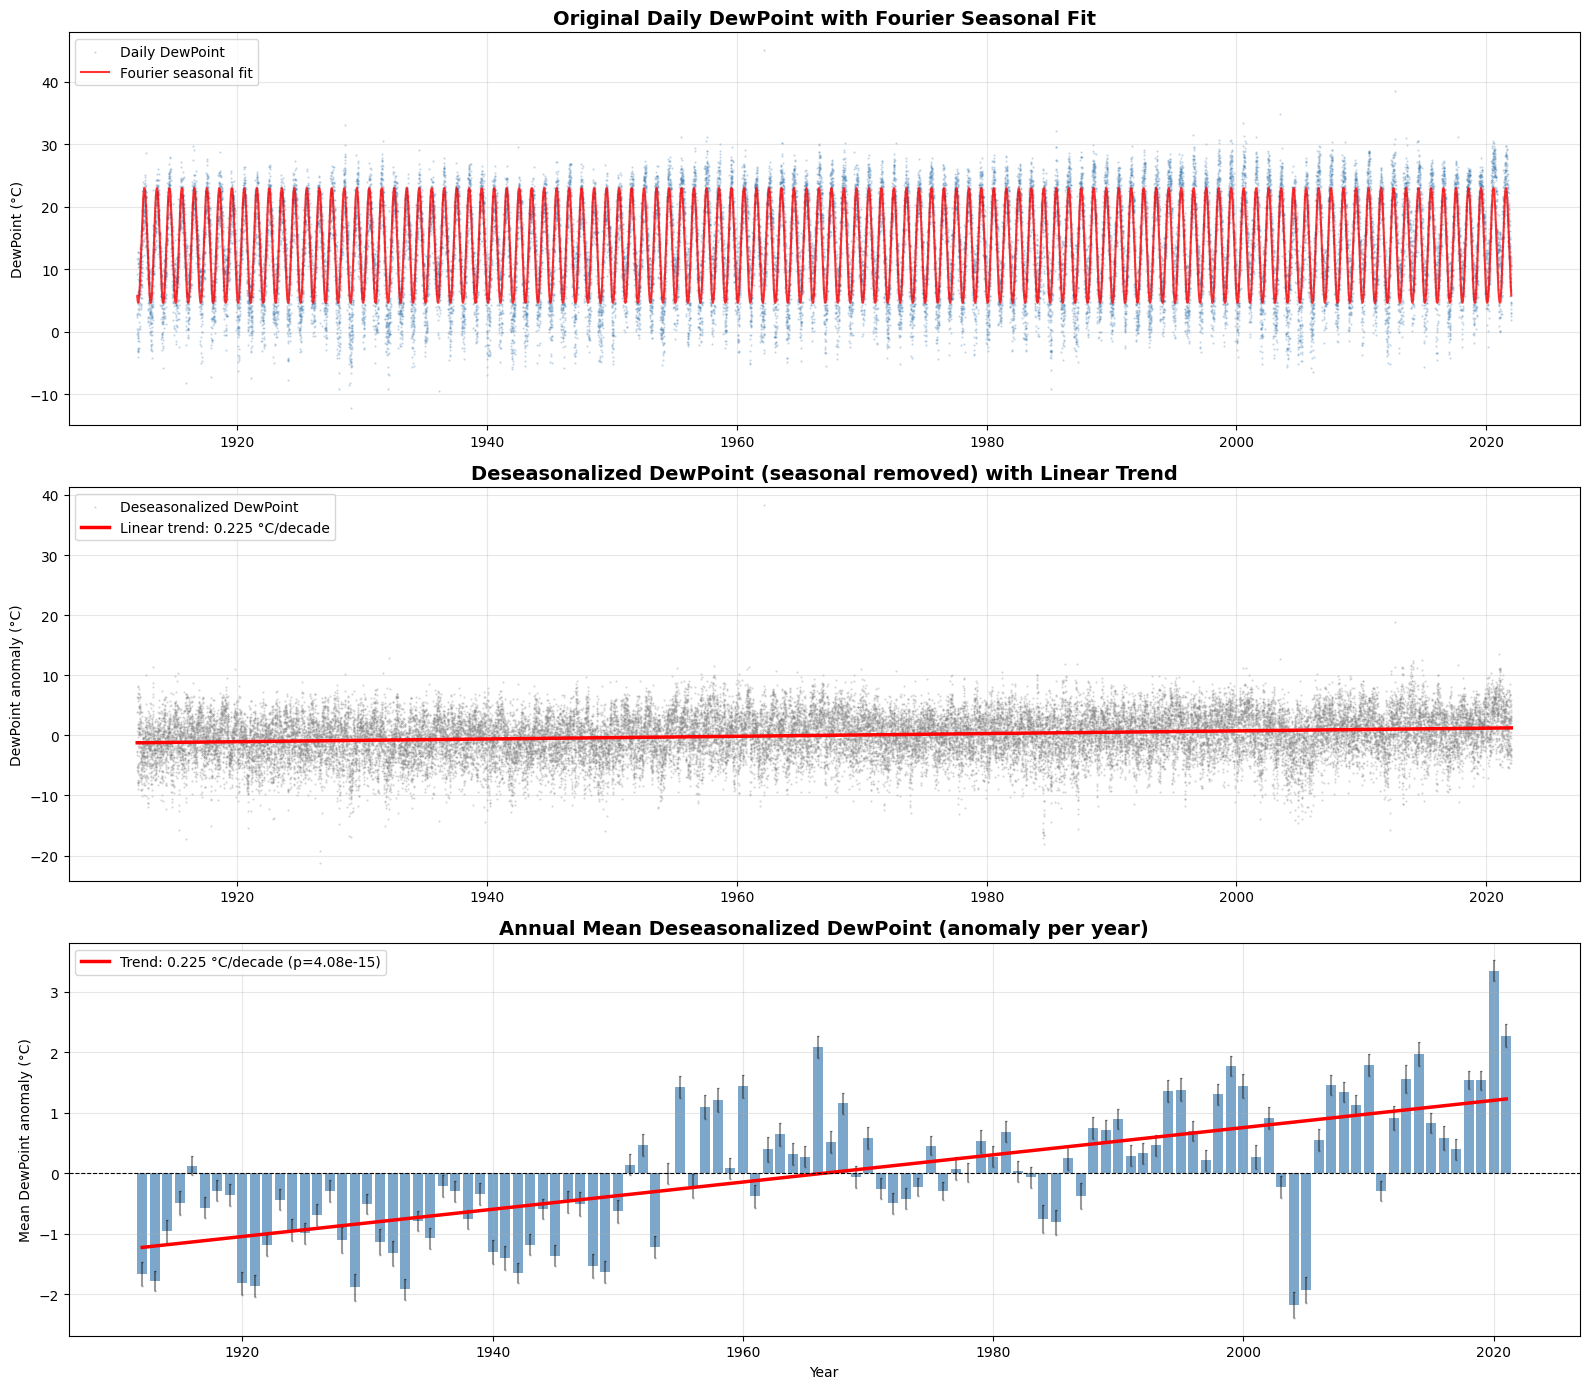


Saved: dewpoint_trend_analysis.png


In [1]:
"""
Seasonal Reverse Transformation & Long-Term DewPoint Trend Analysis
====================================================================
1. Fit sinusoidal (Fourier) seasonal component to daily DewPoint
2. Subtract seasonal component → deseasonalized DewPoint
3. Linear regression: deseasonalized DewPoint ~ Year
4. Statistical test (slope, p-value, confidence interval)
5. Visualization
"""

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy import stats
import matplotlib.pyplot as plt

# ── Load data ────────────────────────────────────────────────────────
df = pd.read_csv("df_linear_merged.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df["Year"] = df["Date"].dt.year
df["DayOfYear"] = df["Date"].dt.dayofyear

# ── Step 1: Fourier seasonal encoding ────────────────────────────────
# First harmonic (captures the dominant yearly cycle)
df["sin1"] = np.sin(2 * np.pi * df["DayOfYear"] / 365.25)
df["cos1"] = np.cos(2 * np.pi * df["DayOfYear"] / 365.25)
# Second harmonic (captures asymmetry in the seasonal shape)
df["sin2"] = np.sin(4 * np.pi * df["DayOfYear"] / 365.25)
df["cos2"] = np.cos(4 * np.pi * df["DayOfYear"] / 365.25)

# Fit seasonal model: DewPoint ~ sin1 + cos1 + sin2 + cos2
seasonal_features = df[["sin1", "cos1", "sin2", "cos2"]].values
seasonal_model = LinearRegression()
seasonal_model.fit(seasonal_features, df["DewPoint"].values)
df["seasonal_fit"] = seasonal_model.predict(seasonal_features)

# ── Step 2: Deseasonalize ────────────────────────────────────────────
df["dew_deseasonalized"] = df["DewPoint"] - df["seasonal_fit"]

# ── Step 3: Linear regression on trend ───────────────────────────────
# Convert date to fractional year for continuous regression
df["year_frac"] = df["Year"] + (df["DayOfYear"] - 1) / 365.25

X_trend = df["year_frac"].values
y_trend = df["dew_deseasonalized"].values

# scipy linregress for full statistics
slope, intercept, r_value, p_value, std_err = stats.linregress(X_trend, y_trend)
r2 = r_value ** 2

# Trend line
df["trend_line"] = slope * X_trend + intercept

# ── Step 4: Print statistics ─────────────────────────────────────────
print("=" * 65)
print("  DewPoint Long-Term Trend Analysis")
print("  (after Fourier seasonal reverse transformation)")
print("=" * 65)
print(f"  Data range       : {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"  Observations     : {len(df):,} daily records")
print()
print("  Seasonal Model (1st + 2nd harmonic):")
print(f"    Intercept (mean DewPoint) : {seasonal_model.intercept_:.4f} °C")
print(f"    sin(2π·doy/365) coeff     : {seasonal_model.coef_[0]:.4f}")
print(f"    cos(2π·doy/365) coeff     : {seasonal_model.coef_[1]:.4f}")
print(f"    sin(4π·doy/365) coeff     : {seasonal_model.coef_[2]:.4f}")
print(f"    cos(4π·doy/365) coeff     : {seasonal_model.coef_[3]:.4f}")
amplitude = np.sqrt(seasonal_model.coef_[0]**2 + seasonal_model.coef_[1]**2)
print(f"    Seasonal amplitude (1st)  : {amplitude:.4f} °C")
print()
print("  Trend Regression (deseasonalized DewPoint ~ Year):")
print(f"    Slope           : {slope:.6f} °C/year")
print(f"    Slope per decade: {slope * 10:.4f} °C/decade")
print(f"    R²              : {r2:.6f}")
print(f"    p-value         : {p_value:.2e}")
print(f"    Std Error       : {std_err:.6f}")

# 95% confidence interval for slope
ci_95 = 1.96 * std_err
print(f"    95% CI for slope: [{slope - ci_95:.6f}, {slope + ci_95:.6f}] °C/year")
print()
if p_value < 0.05:
    direction = "increasing" if slope > 0 else "decreasing"
    print(f"  ✓ SIGNIFICANT (p < 0.05): DewPoint is {direction}")
    print(f"    at {slope * 10:.4f} °C per decade.")
else:
    print(f"  ✗ NOT SIGNIFICANT (p ≥ 0.05): No significant trend detected.")
print("=" * 65)

# ── Step 5: Visualization ────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# --- Panel 1: Original DewPoint with seasonal fit ---
ax1 = axes[0]
ax1.scatter(df["Date"], df["DewPoint"], s=0.3, alpha=0.3, color="steelblue", label="Daily DewPoint")
ax1.plot(df["Date"], df["seasonal_fit"], color="red", linewidth=1.5, alpha=0.8, label="Fourier seasonal fit")
ax1.set_title("Original Daily DewPoint with Fourier Seasonal Fit", fontsize=14, fontweight="bold")
ax1.set_ylabel("DewPoint (°C)")
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)

# --- Panel 2: Deseasonalized DewPoint with trend ---
ax2 = axes[1]
ax2.scatter(df["Date"], df["dew_deseasonalized"], s=0.3, alpha=0.3, color="gray", label="Deseasonalized DewPoint")
ax2.plot(df["Date"], df["trend_line"], color="red", linewidth=2.5, label=f"Linear trend: {slope*10:.3f} °C/decade")
ax2.set_title("Deseasonalized DewPoint (seasonal removed) with Linear Trend", fontsize=14, fontweight="bold")
ax2.set_ylabel("DewPoint anomaly (°C)")
ax2.legend(loc="upper left")
ax2.grid(True, alpha=0.3)

# --- Panel 3: Annual mean deseasonalized DewPoint ---
annual_mean = df.groupby("Year").agg(
    dew_deseas_mean=("dew_deseasonalized", "mean"),
    dew_deseas_std=("dew_deseasonalized", "std"),
).reset_index()

ax3 = axes[2]
ax3.bar(annual_mean["Year"], annual_mean["dew_deseas_mean"], color="steelblue", alpha=0.7, width=0.8)
ax3.errorbar(annual_mean["Year"], annual_mean["dew_deseas_mean"],
             yerr=annual_mean["dew_deseas_std"] / np.sqrt(365),
             fmt="none", color="black", alpha=0.4, capsize=1)

# Trend line on annual means
slope_ann, intercept_ann, r_ann, p_ann, _ = stats.linregress(
    annual_mean["Year"], annual_mean["dew_deseas_mean"]
)
ax3.plot(annual_mean["Year"],
         slope_ann * annual_mean["Year"] + intercept_ann,
         color="red", linewidth=2.5,
         label=f"Trend: {slope_ann*10:.3f} °C/decade (p={p_ann:.2e})")
ax3.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax3.set_title("Annual Mean Deseasonalized DewPoint (anomaly per year)", fontsize=14, fontweight="bold")
ax3.set_xlabel("Year")
ax3.set_ylabel("Mean DewPoint anomaly (°C)")
ax3.legend(loc="upper left")
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("dewpoint_trend_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: dewpoint_trend_analysis.png")